In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
AQI = pd.read_csv('data/01-interim/AQIinterim.csv')

In [3]:
AQI.Date = pd.to_datetime(AQI.Date, format='%Y-%m-%d')

In [4]:
# get monthly averages
AQImonthly = AQI.groupby(pd.PeriodIndex(AQI['Date'], freq = 'M'))['AQI'].mean().reset_index()
AQImonthly.Date = AQImonthly['Date'].dt.to_timestamp()


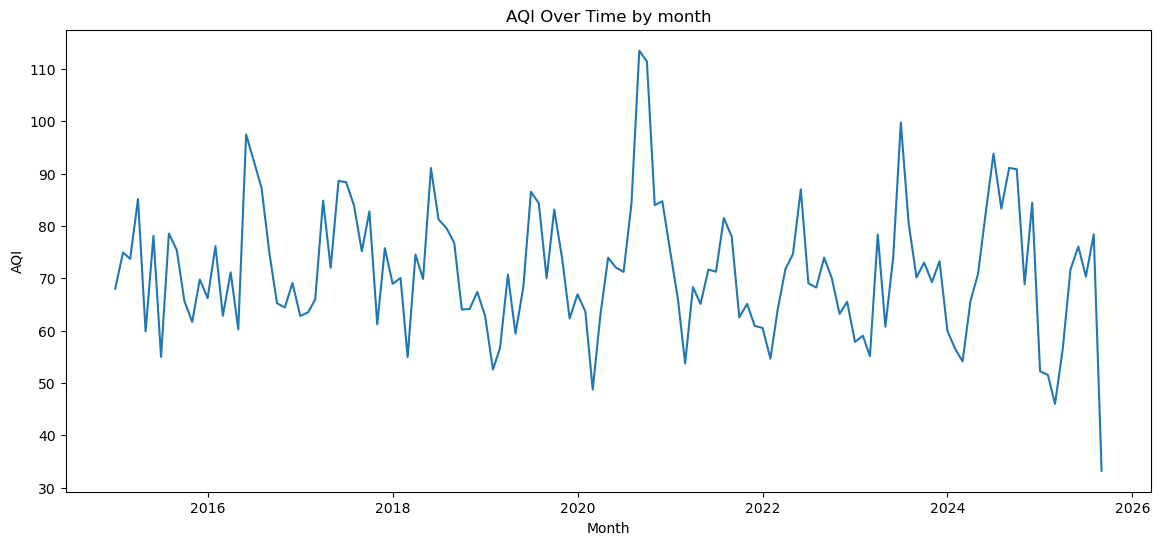

In [5]:
plt.figure(figsize=(14,6))
plt.plot(AQImonthly['Date'], AQImonthly['AQI'])
plt.title('AQI Over Time by month')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.show()

In [6]:
from pathlib import Path

raw_dir = Path("data/00-raw")

gasoline = pd.read_csv(
    raw_dir / "gasoline.csv",
    encoding="latin1",
    header=None,
    names=["date", "gasoline_price"]
)

#convert to datetime
gasoline.date = pd.to_datetime(gasoline.date, format='%m/%d/%Y')


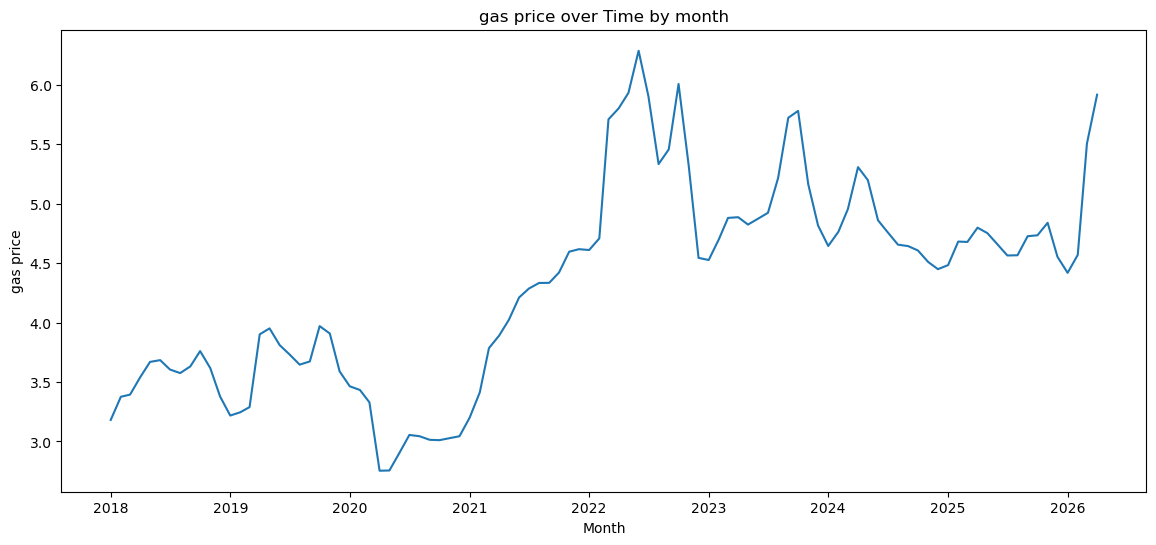

In [7]:
plt.figure(figsize=(14,6))
plt.plot(gasoline['date'], gasoline['gasoline_price'])
plt.title('gas price over Time by month')
plt.xlabel('Month')
plt.ylabel('gas price')
plt.show()

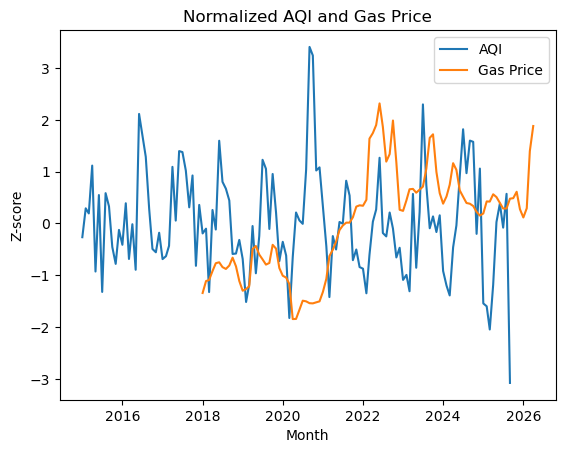

In [8]:
# overlay both?

from scipy.stats import zscore

plt.plot(AQImonthly['Date'], zscore(AQImonthly['AQI']), label='AQI')
plt.plot(gasoline['date'], zscore(gasoline['gasoline_price']), label='Gas Price')
plt.xlabel('Month')
plt.ylabel('Z-score')
plt.title('Normalized AQI and Gas Price')
plt.legend()
plt.show()


From this graph we can see that there is some correlation between AQI and gas price, in particular the peaking behavior. We see that there are small peaks in both gas price and AQI lining up in the 2018-2029 time period and also the 2022-2023 time period, but in 2020-2022 specifically there isn't as much of a similarity (likely due to COVID messing with gas prices and air quality). Also, the extreme inflation seen after 2020 in gas price makes it difficult to compare the before and after, since gas price changed so much while AQI stays relatively stable.

However, we expect the opposite trend to be true: when gas price peaks, AQI should decrease. When gas price goes up, we expect people to drive less, thus improving the air quality, which corresponds with a lower AQI.

So what if we look at the inverse of gas price? (the reciprocal)

In [9]:
AQImonthly = AQImonthly.rename(columns = {'Date': 'date'})
combined_date = pd.merge(AQImonthly, gasoline, how = 'inner', on = 'date')
combined = combined_date.drop(columns = 'date')
combined

,AQI,gasoline_price
0,68.935484,3.181
1,70.071429,3.376
2,54.935484,3.394
3,74.533333,3.540
4,69.870968,3.669
...,...,...
88,71.645161,4.752
89,76.066667,4.657
90,70.322581,4.564
91,78.387097,4.566


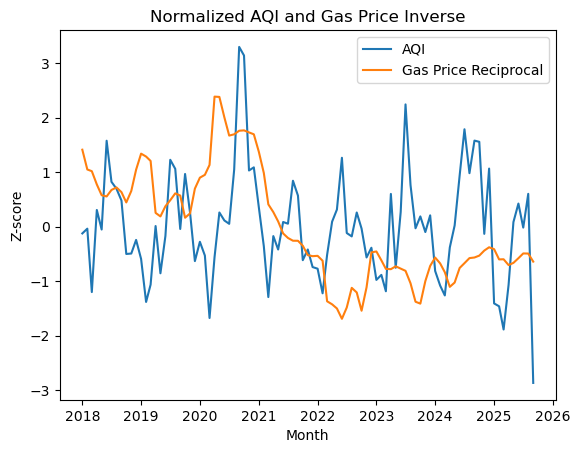

In [10]:
combined_reciprocal = combined_date
combined_reciprocal['gasoline_price_reciprocal'] = 1/(combined_reciprocal['gasoline_price'])
combined_reciprocal = combined_reciprocal.drop(columns = 'gasoline_price')

plt.plot(combined_reciprocal['date'], zscore(combined_reciprocal['AQI']), label='AQI')
plt.plot(combined_reciprocal['date'], zscore(combined_reciprocal['gasoline_price_reciprocal']), label='Gas Price Reciprocal')
plt.xlabel('Month')
plt.ylabel('Z-score')
plt.title('Normalized AQI and Gas Price Inverse')
plt.legend()
plt.show()

Let's run some Granger tests. Granger tests are used to see if one time series can be a useful predictor for another time series, in this case our gas price as a predictor for AQI.
The null hypothesis for a Granger test is that time series A is not a useful predictor for time series B. A low p-value for this test indicates that our results are weird enough that the probability of random chance creating results this weird or greater is the p-value, essentially meaning that the two time series are correlated and A can predict B.
Granger tests also include a variable called time lag, which essentially is the maximum amount of lag we expect from A causing B (i.e. a change in A is reflected in B some time later). Here we set our time lag to 1 month, since we do expect lag (see the background).
Source: https://machinelearningplus.com/time-series/granger-causality-test-in-python/

In [11]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag = 1 # because we expect there to be some lag from gas price changes to AQI because it takes time for people to refill their gas, 1 here indicates 1 month, should be the max lag

def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    

    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

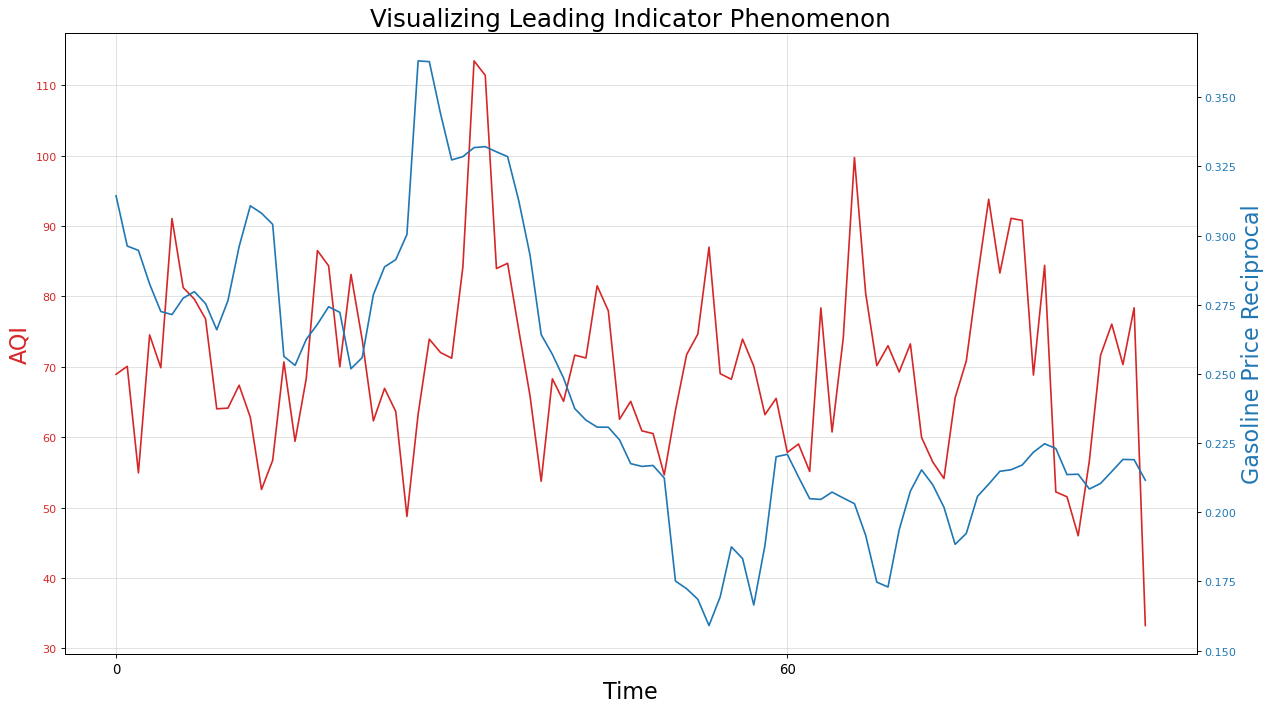

In [12]:
# Granger test on reciprocal gas price
x = combined_reciprocal.index
y1 = combined_reciprocal['AQI'] #result
y2 = combined_reciprocal['gasoline_price_reciprocal'] #predictor

# Plot Line1 (Left Y Axis)
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)
ax1.plot(x, y1, color='tab:red')

# Plot Line2 (Right Y Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(x, y2, color='tab:blue')

# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('AQI', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("Gasoline Price Reciprocal", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_xticks(np.arange(0, len(x), 60))
ax2.set_xticklabels(x[::60], rotation=90, fontdict={'fontsize':10})
ax2.set_title("Visualizing Leading Indicator Phenomenon", fontsize=22)
fig.tight_layout()
plt.show()

In [13]:
combined_reciprocal_granger = combined_reciprocal.drop(columns = 'date')
grangers_causation_matrix(combined_reciprocal_granger, variables = combined_reciprocal_granger.columns)  

,AQI_x,gasoline_price_reciprocal_x
AQI_y,1.00,0.4744
gasoline_price_reciprocal_y,0.65,1.0000


P-value for gas price reciprocal predicting AQI is very high, indicating that gas price reciprocal is a weak indicator of AQI.
Looking back at the original graph, what if our original hypothesis was false and instead just the gas price by itself is correlated with AQI? One reason for this could be that there's some confounding variable that we don't know (for example, the weather: maybe bad weather (which causes bad AQI) makes people generally more unhappy and worsens the economic state and gas price of San Diego). To test this, we can run a Granger test on flat gas price.

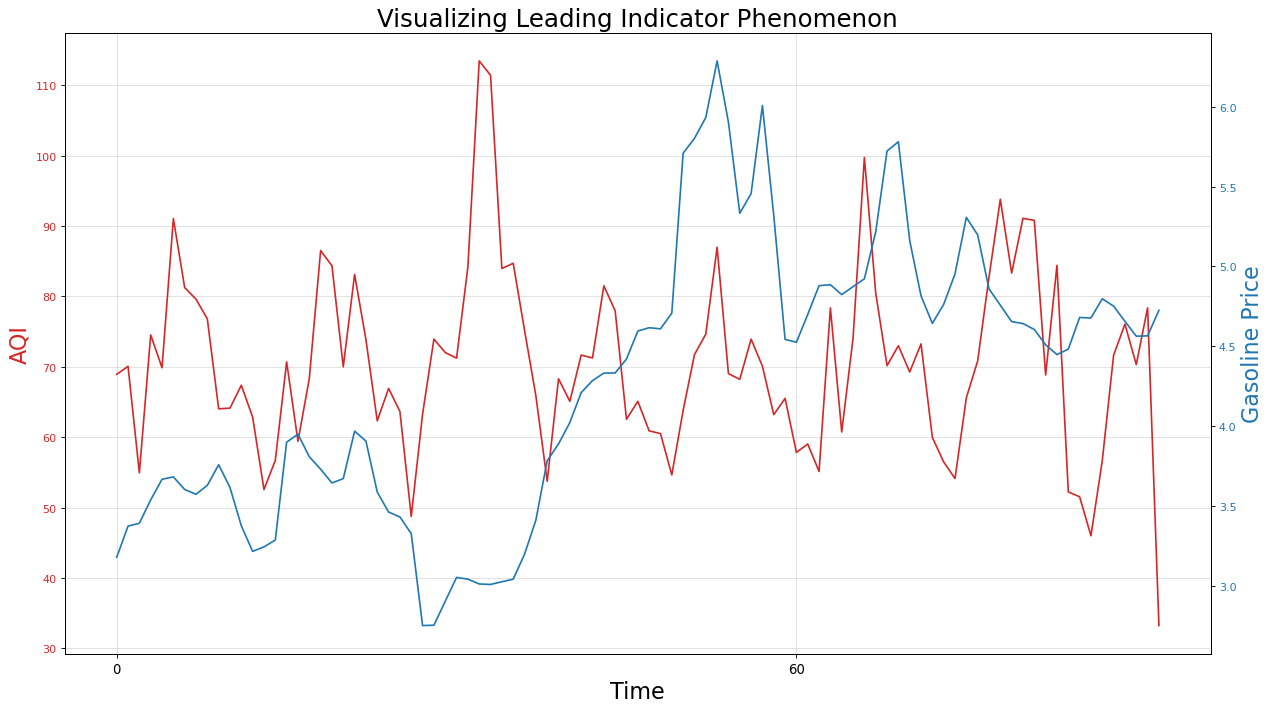

In [14]:
# Granger test on flat gas price
x = combined.index
y1 = combined['AQI'] #result
y2 = combined['gasoline_price'] #predictor

# Plot Line1 (Left Y Axis)
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)
ax1.plot(x, y1, color='tab:red')

# Plot Line2 (Right Y Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(x, y2, color='tab:blue')

# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('AQI', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("Gasoline Price", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_xticks(np.arange(0, len(x), 60))
ax2.set_xticklabels(x[::60], rotation=90, fontdict={'fontsize':10})
ax2.set_title("Visualizing Leading Indicator Phenomenon", fontsize=22)
fig.tight_layout()
plt.show()

In [15]:
grangers_causation_matrix(combined, variables = combined.columns)  

,AQI_x,gasoline_price_x
AQI_y,1.0000,0.6563
gasoline_price_y,0.3203,1.0000


In this matrix we see p values of 0.66, which is very high. This means that we fail to reject the null hypothesis that gasoline price does not granger cause AQI.

Essentially this test is telling us that the gasoline price time series isn't helpful in explaining the AQI values.

What if we look at 2018-2019 and 2022-2023 time periods individually? Breaking the dataset into smaller time periods of before and after COVID could lessen its impact on our results, since we're not controlling for it as a mediator variable.

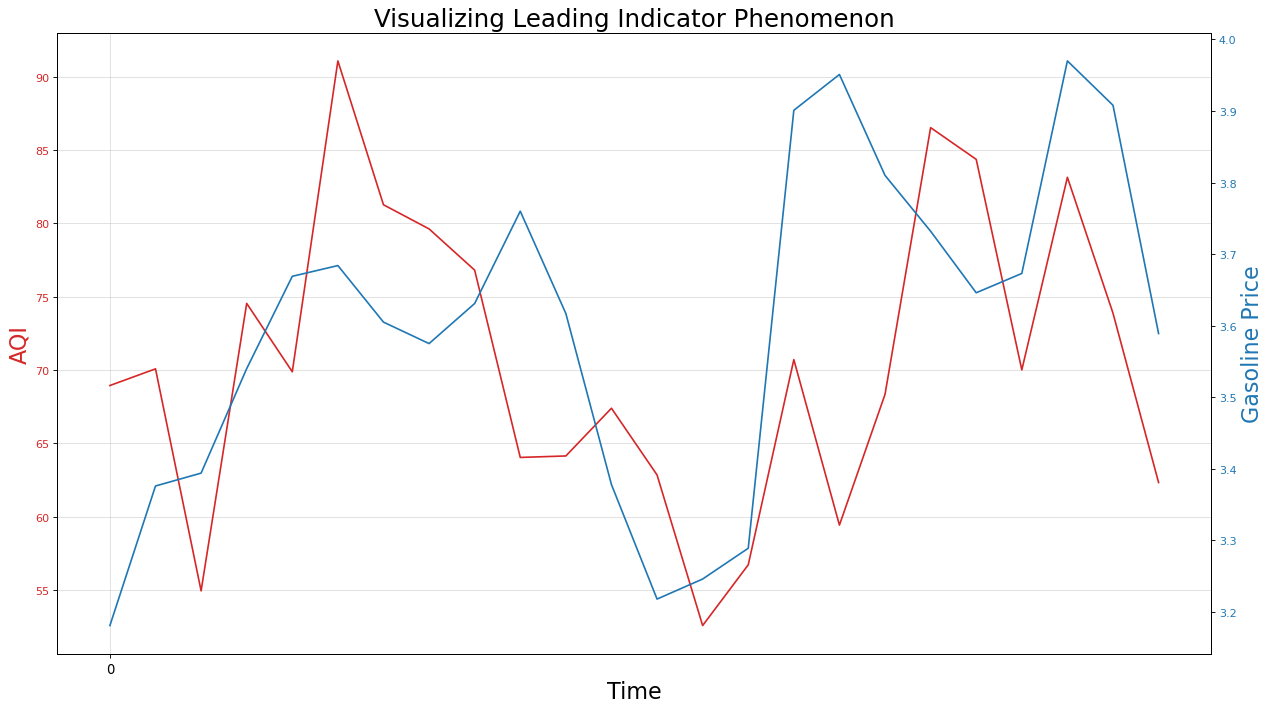

,AQI_x,gasoline_price_x,gasoline_price_reciprocal_x
AQI_y,1.0000,0.3468,0.2915
gasoline_price_y,0.8225,1.0000,0.9138
gasoline_price_reciprocal_y,0.8371,0.9918,1.0000


In [16]:
# 2018 - 2029
combined_date
combined_a = combined_date.loc[combined_date['date'] < '2020-01-01']
combined_a = combined_a.drop(columns = 'date') # drop date for granger test

#plot everything again
x = combined_a.index
y1 = combined_a['AQI'] #result
y2 = combined_a['gasoline_price'] #predictor

# Plot Line1 (Left Y Axis)
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)
ax1.plot(x, y1, color='tab:red')

# Plot Line2 (Right Y Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(x, y2, color='tab:blue')

# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('AQI', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("Gasoline Price", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_xticks(np.arange(0, len(x), 60))
ax2.set_xticklabels(x[::60], rotation=90, fontdict={'fontsize':10})
ax2.set_title("Visualizing Leading Indicator Phenomenon", fontsize=22)
fig.tight_layout()
plt.show()

grangers_causation_matrix(combined_a, variables = combined_a.columns)  

Here gasoline price becomes a better predictor for AQI. However, the p value is still high (0.35), so we still fail to reject the null.

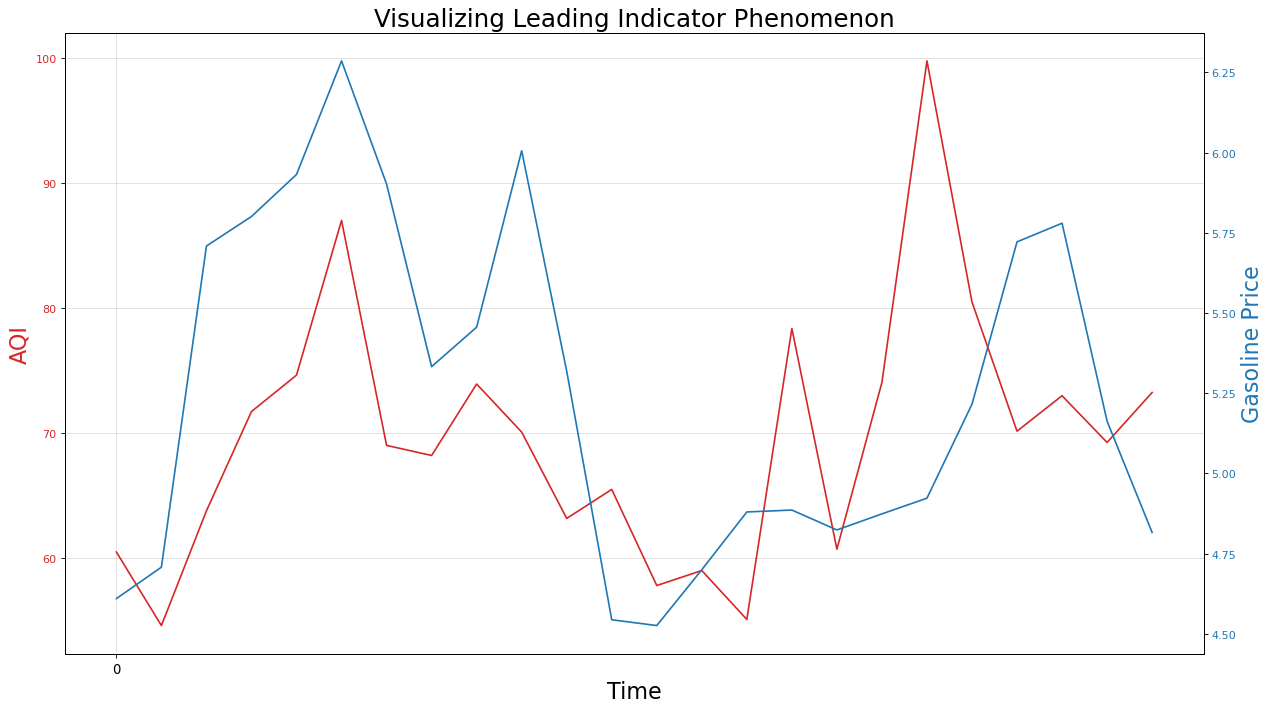

,AQI_x,gasoline_price_x,gasoline_price_reciprocal_x
AQI_y,1.0000,0.5447,0.4407
gasoline_price_y,0.5774,1.0000,0.6603
gasoline_price_reciprocal_y,0.5574,0.8453,1.0000


In [17]:
# ok now let's look at 2022-2024
combined_b = combined_date.loc[combined_date['date'] < '2024-01-01']
combined_b = combined_b.loc[combined_b['date'] >= '2022-01-01']
combined_b = combined_b.reset_index(drop = True)
combined_b = combined_b.drop(columns = 'date') # drop date for granger test

#plot everything again
x = combined_b.index
y1 = combined_b['AQI'] #result
y2 = combined_b['gasoline_price'] #predictor

# Plot Line1 (Left Y Axis)
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)
ax1.plot(x, y1, color='tab:red')

# Plot Line2 (Right Y Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(x, y2, color='tab:blue')

# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('AQI', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("Gasoline Price", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_xticks(np.arange(0, len(x), 60))
ax2.set_xticklabels(x[::60], rotation=90, fontdict={'fontsize':10})
ax2.set_title("Visualizing Leading Indicator Phenomenon", fontsize=22)
fig.tight_layout()
plt.show()

grangers_causation_matrix(combined_b, variables = combined_b.columns)  


Not a great correlation here either. 

Let's try to build a regression model:

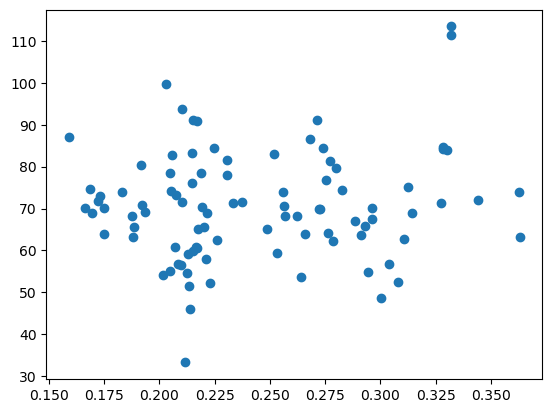

In [18]:
plt.scatter(x = combined_date['gasoline_price_reciprocal'], y = combined_date['AQI'])

In [19]:
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

result_reciprocal = smf.ols(formula = 'AQI ~ gasoline_price_reciprocal', data = combined_date).fit()

result_reciprocal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    AQI   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.669
Date:                Tue, 02 Jun 2026   Prob (F-statistic):              0.200
Time:                        15:47:18   Log-Likelihood:                -369.67
No. Observations:                  93   AIC:                             743.3
Df Residuals:                      91   BIC:                             748.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    62.0522      6.720      9.234      0.000      48.704      75.401
gasoline_price_reciprocal    34.8918     27.010      1.292      0.200     -18.760      88.544
==============================================================================
Omnibus:                        6.355   Durbin-Watson:                   0.926
Prob(Omnibus):                  0.042   Jarque-Bera (JB):                6.339
Skew:                           0.433   Prob(JB):                       0.0420
Kurtosis:                       3.942   Cond. No.                         21.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

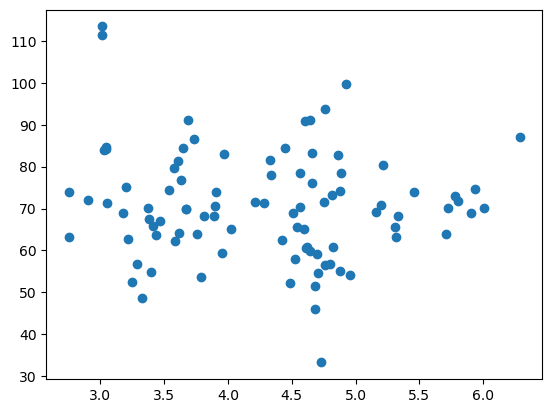

In [20]:
plt.scatter(x = combined_date['gasoline_price'], y = combined_date['AQI'])

In [21]:
result_flat = smf.ols(formula = 'AQI ~ gasoline_price', data = combined_date).fit()

result_flat.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    AQI   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.8426
Date:                Tue, 02 Jun 2026   Prob (F-statistic):              0.361
Time:                        15:47:18   Log-Likelihood:                -370.09
No. Observations:                  93   AIC:                             744.2
Df Residuals:                      91   BIC:                             749.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         76.8151      6.952     11.049      0.000      63.005      90.625
gasoline_price    -1.4645      1.595     -0.918      0.361      -4.634       1.705
==============================================================================
Omnibus:                        7.356   Durbin-Watson:                   0.921
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                7.900
Skew:                           0.459   Prob(JB):                       0.0193
Kurtosis:                       4.094   Cond. No.                         23.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The linear regression shows very poor R^2 values and adj R^2 values for both the inverse and flat models. 